<font size=6, color='navy'><b>Анализ гипотез и результатов А/В-теста относительно выручки интернет-магазина</font>

# Введение

<font color='navy'><b>Целевая задача Заказчика - увеличение выручки интернет-магазина</b><br>
<font color='black'>В рамках реализации задачи <u>было выдвинуто 9 гипотез, осуществление которых может привести к искомому результату - росту выручки магазина</u>.<br>Реализация всех 9 мероприятий  приведет к значительным расходам, эффективность которых не гарантирована.<br>В целях оптимизации расходов Заказчика <u>необходимо определить наиболее приоритетную гипотезу и оценить результаты ее А/В-тестирования.</u>

<Font color='navy'><b><i><u>Цели исследования</font>

Целями настоящего исследования является определение для интернет-магазина
- наиболее приоритетной гипотезы, реализация которой с наибольшей вероятностью позволит увеличить его выручку
- оценить результаты А/В-тестирования гипотезы и целесообразность его продолжения

<Font color='navy'><b><i><u>Задачи исследования</font>

<font color='black'>Задачами исследования являются<br>- анализ и ранжирование гипотез методами ICE и RICE<br>- анализ ключевых бизнес-метрик по группам А/В-тестировани: конверсия, выручка, средний чек<br> - оценка статистической значимости различий в конверсии и среднем чеке по группам А/В-тестирования<br> 

<Font color='navy'><b><i><u>План исследования</font>
1. Обзор данных
    - загрузка библиотек
    - загрузка и обзор данных
2. Анализ и приоритезация гипотез методами ICE и RICE
3. Анализ А/В- теста
    - проверка и подготовка данных к А/В тесту
    - расчет и анализ кумулятивных метрик по группам
    - анализ выбросов - аномальные значения
    - расчет и анализ статистической значимости ключевых метрик по группам

# Обзор данных

## Загрузка библиотек

In [1]:
import pandas as pd
import datetime as dt
from scipy import stats as st
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters
import warnings
# конвертеры, которые позволяют использовать типы pandas в matplotlib  
register_matplotlib_converters()
pd.set_option('display.max_colwidth', 125)

## Загрузка и обзор файлов с данными

### Файл с данными о гипотезах - hypotheses

In [2]:
hypotheses = pd.read_csv('C:\\Users\\Svetlana\\DA\\projects\\hypotheses_A&B_test\\hypotheses.csv')

In [3]:
hypotheses.info()
hypotheses.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 492.0+ bytes


,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5


In [4]:
# приведем к стандарту в названиях колонок - уберем заглавные буквы
hypotheses.columns = [x.lower() for x in hypotheses.columns.values]
hypotheses.columns

Index(['hypothesis', 'reach', 'impact', 'confidence', 'efforts'], dtype='object')

<font color='DarkBlue'>Файл предоставляет информацию о 9 гипотезах, проранжированных по уровню охвата (Reach), влияния на достижение цели (Impact), уверенности в том, что идея действительно окажет прогнозируемое воздействие (Confidence) и усилий по проверке гипотезы (Efforts)</font>

### Файл с данными о заказах - orders

In [5]:
orders = pd.read_csv('https://code.s3.yandex.net/datasets/orders.csv')

In [6]:
orders.info()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


In [7]:
# приведем название колонок transactionID и visitorId к более стандартному виду
orders = orders.rename(columns = {'transactionId' : 'order_id', \
                       'visitorId' : 'visitor_id'})
orders.columns

Index(['order_id', 'visitor_id', 'date', 'revenue', 'group'], dtype='object')

In [8]:
# проверим наличие явных дубикатов в записях
orders.duplicated().sum()

np.int64(0)

In [9]:
# изменим формат данных в колонке date
orders['date'] = pd.to_datetime(orders['date']).dt.date

In [10]:
print('Период анализа: с', orders['date'].min(), 'по', orders['date'].max())

Период анализа: с 2019-08-01 по 2019-08-31


<font color='DarkBlue'>Файл с данными о заказах - orders, содержит 1197 записей о заказах пользователей в период с 01 по 31 августа 2019 года с указанием даты и стоимости заказа, а также принадлежности к группе в рамках проведения А/В-теста. Явных дубликатов данных в данных нет.</font>

### Файл с данными о посещениях интернет-магазина - visitors

In [11]:
visitors = pd.read_csv('https://code.s3.yandex.net/datasets/visitors.csv')

In [12]:
visitors.info()
visitors.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [13]:
#проверим наличие явных дубликатов записей
visitors.duplicated().sum()

np.int64(0)

In [14]:
#изменим формат данных в колонке date
visitors['date'] = pd.to_datetime(visitors['date']).dt.date

In [15]:
print('Период анализа: с', visitors['date'].min(), 'по', visitors['date'].max())

Период анализа: с 2019-08-01 по 2019-08-31


<font color='DarkBlue'>Файл с данными о пользователях содрежит информацию о ежедневном количестве пользователей в период с 1 по 31 августа 2019 по группам А/В-тестирования</font>

## Резюме

1. Для исследования предоставлены
    - данные о 9 прорейтингованных гипотезах о возможных действиях, направленных на повышение выручки интернет-магазина
    - 2 датасета о количестве и стоимости заказов и количестве посетителей интернет-магазина в период с 01 по 31 августа 2019 года с разбивкой по группам А/В-тестирования
        - файл с данными о заказах - orders, содержит 1197 записей о заказах пользователей
        - файл с данными о пользователях - visitors, содержит 62 записи - информация о ежедневном количестве пользователей в период с 1 по 31 августа 2019 по 2м группам
2. Пропусков и дубликатов в данных нет
3. Приведены к стандарту наименования столбцов и изменен формат данных о датах

# Приоритезация гипотез

## Приоритизация гипотез методом ICE

In [16]:
# рассичтаем ICE
hypotheses['ice'] = round((hypotheses['impact'] * hypotheses['confidence']) / hypotheses['efforts'])
hypotheses.sort_values(by='ice',ascending=False).style.background_gradient(sns.light_palette('navy', as_cmap=True))

,hypothesis,reach,impact,confidence,efforts,ice
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.000000
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.000000
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.000000
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8.000000
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7.000000
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.000000
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.000000
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.000000
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.000000


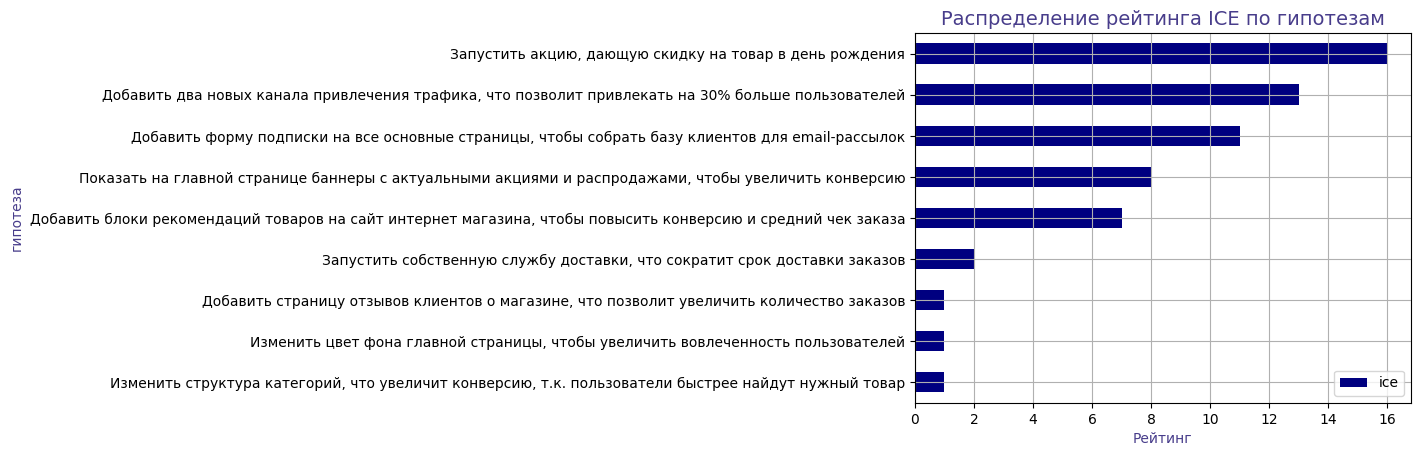

In [17]:
hypotheses.sort_values(by='ice', ascending=True).plot(x='hypothesis', y='ice', \
                        kind = 'barh', color='navy', \
                        grid=True)
plt.xlabel('Рейтинг', fontsize=10, color='darkslateblue')
plt.ylabel('гипотеза', fontsize=10, color='darkslateblue')
plt.title('Распределение рейтинга ICE по гипотезам', fontsize=14, color='darkslateblue')
plt.show();

<font color='DarkBlue'>Как видно из таблицы выше:</font><br>
<font color='DarkBlue'><b>- наиболее приритетной для анализа (ICE score = 16.0) является 9 гипотеза о возможном варианте повышения выручки интренет-магазина - "Запуск акции, дающей скидку на товар в день рождения"</b>, которая одновременно получила и 9 рейтинг влияния (impact), и 9 рейтинг по уверенности о результативности идеи (confidence)</font><br>
<font color='DarkBlue'>- также с высоким рейтингом гипотезы 1 ("Добавление двух новых каналов привлечения трафика") и 8 ("Добавление формы подписки на все основные страницы")</font><br>

## Приоритизация гипотез методом RICE

In [18]:
# рассичтаем RICE
hypotheses['rice'] = round((hypotheses['reach'] * hypotheses['impact'] * hypotheses['confidence']) / hypotheses['efforts'])
hypotheses.sort_values(by='rice',ascending=False).style.background_gradient(sns.light_palette('teal', as_cmap=True))\
            .format({'ice':'{:.0f}', 'rice': '{:.0f}'})

,hypothesis,reach,impact,confidence,efforts,ice,rice
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11,112
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7,56
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13,40
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8,40
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16,16
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1,9
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2,4
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1,4
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1,3


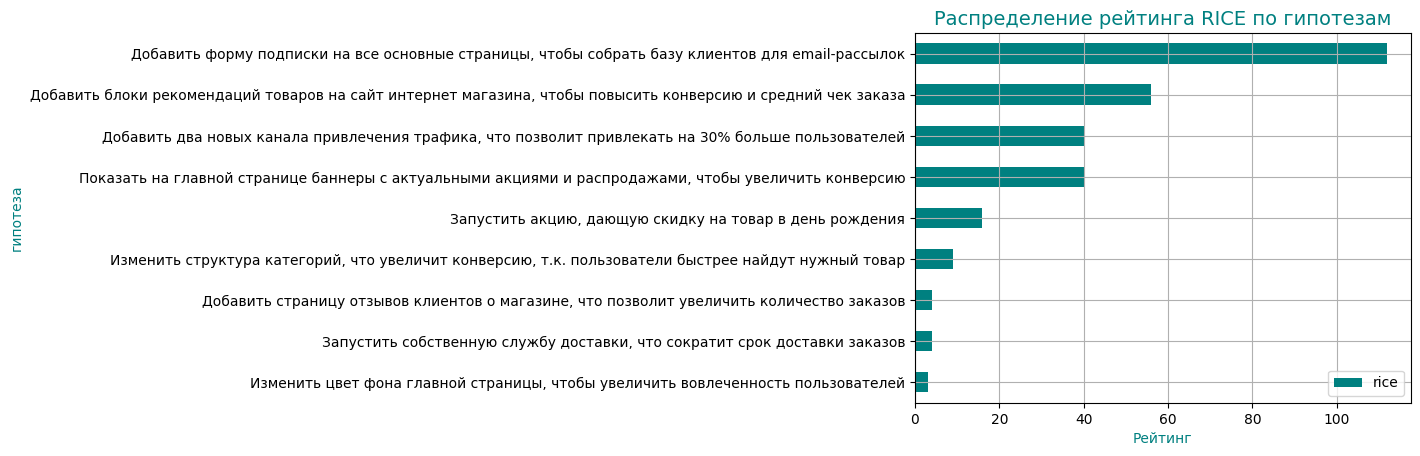

In [19]:
hypotheses.sort_values(by='rice', ascending=True).plot(x='hypothesis', y='rice', \
                        kind = 'barh', color='teal', \
                        grid=True)
plt.xlabel('Рейтинг', fontsize=10, color='teal')
plt.ylabel('гипотеза', fontsize=10, color='teal')
plt.title('Распределение рейтинга RICE по гипотезам', fontsize=14, color='teal')
plt.show();

<font color='Darkblue'>Приоритезация гипотез методом RICE показала следующие результаты:<font><br>
<font color='Darkblue'><b>- наиболее приритетной для анализа (RICE score = 112.0) является 8 гипотеза о возможном варианте повышения выручки интренет-магазина - "Добавление формы подписки на все основные страницы"</b>, получившая самый высойкий рейтинг по охвату и средний рейтинг по услилиям<font><br>
<font color='Darkblue'>- также с относительно-высоким рейтингом RICE оказалась 3-яя гипотеза - "Добавление блоков рекомендаций товаров на сайт интернет магазина", с рейтингом охвата - 8<font><br>

## Резюме

<font color='navy'>Приоритезация гипотез методами ICЕ и RICE показала различающийся результат:</font><br>
<font color='navy'>- исходя из результатов ранжирования <b>методом ICE</b> в дальнейшем в первую очередь целесообразно анализировать <b>гипотезу о запуске акции, дающей скидку на товар в день рождения</b>, тогда как ранжирование <b>методом RICE</b> определило как более приоритетную <b>гипотезу о целесообразности добавления формы подписки на все основные страницы</font><br>
<font color='navy'>Разница в результатах ранжирования связана в первую очередь с фактором охвата (reach) аудитории, которую затронет изменение, учитываемом при расчете ранга методом RICE.</font><br>

<font color='navy'>С учетом того, что значимость фактора охвата достаточно высока для интернет-магазина, и при условии, что ранги, связанные с влиянием на достижение цели и уверенностью в том, что идея действительно окажет прогнозируемое воздействие, достаточно высоки,<b> предлагается для дальнейшего анализа в первую очередь рассматривать гипотезу о целесообразности добавления формы подписки на все основные страницы</b>, которая позволит собрать базу клиентов для email-рассылок</font>

# Анализ А/В-теста

## Проверка данных - подготовка к А/В-тесту

Перед началом анализа А/В-теста проверим корректность формирования групп и достаточность количества наблюдений, для чего:
1. определим количество посетителей по группам и оценим статистичечскую значимость разницы (если таковая обнаружится)
2. определим количество покупок по группам и оценим статистичечскую значимость разницы (если таковая обнаружится)
3. оценим относительную разницу в конверсии по группам и определим достаточность выборки
5. определим наличие/отсутствие пересечения групп по пользователям
6. посмотрим наличие выбросов и аномалий

### Количество посетителей по группам и статитстическая значимость различий

In [20]:
print('Всего интернет-магазин посетили {:,.0f} раз'.format(visitors['visitors'].sum()))
print('Посещений группы А {:,.0f}'.format(visitors[visitors['group']=='A']['visitors'].sum()))
print('Посещений группы B {:,.0f}'.format(visitors[visitors['group']=='B']['visitors'].sum()))
print('Разница между количеством посещений группы А и группы В составляет {:.2%}' \
      .format(abs(visitors[visitors['group']=='A']['visitors'].sum() - visitors[visitors['group']=='B']['visitors'].sum()) / \
                  visitors[visitors['group']=='A']['visitors'].sum()))

Всего интернет-магазин посетили 37,652 раз
Посещений группы А 18,736
Посещений группы B 18,916
Разница между количеством посещений группы А и группы В составляет 0.96%


In [21]:
results = st.mannwhitneyu(visitors[visitors['group']=='A']['visitors'], \
                             visitors[visitors['group']=='B']['visitors'])
alpha = 0.05

if results.pvalue < alpha:
    print('Разница в количестве посетителей в группах A и B статистически значима: p-value - {0:.3f}'.format(results[1]))
else:
    print('Разница в количестве посетителей в группах A и B статистически НЕ значима: p-value - {0:.3f}'.format(results[1]))

Разница в количестве посетителей в группах A и B статистически НЕ значима: p-value - 0.730


### Количество покупок по группам и относительная разница конверсии по группам

In [22]:
orders_a = len(orders[orders['group']=='A'])
orders_b = len(orders[orders['group']=='B'])
print(f'Всего заказов в интернет-магазине за анализируеый период осуществлено {len(orders)}')
print(f'- по группе A сделано {orders_a} заказов')
print(f'- по группе B сделано {orders_b} заказов')
print('Разница между количеством заказов группы А и группы В составляет {:.2%}' \
      .format(abs(orders_a - orders_b) / orders_b))

Всего заказов в интернет-магазине за анализируеый период осуществлено 1197
- по группе A сделано 557 заказов
- по группе B сделано 640 заказов
Разница между количеством заказов группы А и группы В составляет 12.97%


In [23]:
orders_results = st.mannwhitneyu(orders[orders['group']=='A']['order_id'], \
                             orders[orders['group']=='B']['order_id'])
alpha = 0.05

if results.pvalue < alpha:
    print('Разница в количестве заказов в группах A и B статистически значима: p-value - {0:.3f}'.format(results[1]))
else:
    print('Разница в количестве заказов в группах A и B статистически НЕ значима: p-value - {0:.3f}'.format(results[1]))

Разница в количестве заказов в группах A и B статистически НЕ значима: p-value - 0.730


### Относительная разница конверсии по группам и достаточность выборки

In [24]:
conversionA = len(orders[orders['group']=='A']) / visitors[visitors['group']=='A']['visitors'].sum() 
conversionB = len(orders[orders['group']=='B']) / visitors[visitors['group']=='B']['visitors'].sum()

print('Конверсия группы А: {:.1%}'.format(conversionA))
print('Конверсия группы В: {:.1%}'.format(conversionB))
print('Относительное изменение конверсии: {:.1%}'.format(abs(1-(conversionA/conversionB))))

Конверсия группы А: 3.0%
Конверсия группы В: 3.4%
Относительное изменение конверсии: 12.1%


Для оценки достаточности выборки воспользуемся он-лайн калькулятором '//evanmiller.org/ab-testing/sample-size.html' передав в него значение конверсии группы А 3.0% и относительное зменение конверсии 12.1%

В соответсвии с расчетом он-лайн калькулятора, **размер выборки должен составлять 35,855 посещений**, что меньше, чем общее количество посещений представленных в датасете - visitors

### Пересечение групп по пользователей

In [25]:
visitor_id_a = orders[orders['group'] == 'A']['visitor_id'].unique()
visitor_id_b = orders[orders['group'] == 'B']['visitor_id'].unique()
visitors_intersection = pd.Series(list(set(visitor_id_a).intersection(set(visitor_id_b))))
print('Всего уникальных пользователей в данных о заказах {}'.format(orders['visitor_id'].nunique()))
print('Выявлено {} посетителей, учетнных как в группе А, так и в группе В'.format(visitors_intersection.count()))
print('Посетители, учетнные в обеих группах составляют {:.1%} от общего количества уникальных пользователей магазина'.format(visitors_intersection.count() / orders['visitor_id'].nunique()))

Всего уникальных пользователей в данных о заказах 1031
Выявлено 58 посетителей, учетнных как в группе А, так и в группе В
Посетители, учетнные в обеих группах составляют 5.6% от общего количества уникальных пользователей магазина


In [26]:
# посмотрим сколько покупок и на какую сумму совершили задублированные посетители
orders_intersection = orders.query('visitor_id in @visitors_intersection')
intersection_orders_share = orders_intersection['order_id'].count() / orders['order_id'].count()
intersection_revenue_share = orders_intersection['revenue'].sum() / orders['revenue'].sum()
print('Всего посетители, учтенные в обеих группах, совершили {} покупок'.format(orders_intersection['order_id'].count()), 'что составляет {:.2%} всех покупок в интерент магазине'.format(intersection_orders_share))
print('Общая выручка от посетителей, учтенныых в обеих группах, составляет {:,.0f}'.format(orders_intersection['revenue'].sum()), 'что составляет {:.2%} выручки от всех покупок в интерент магазине'.format(intersection_revenue_share))

Всего посетители, учтенные в обеих группах, совершили 181 покупок что составляет 15.12% всех покупок в интерент магазине
Общая выручка от посетителей, учтенныых в обеих группах, составляет 1,558,935 что составляет 15.60% выручки от всех покупок в интерент магазине


In [27]:
# несмотря на высокую долю количества  и стоимости заказов, осуществвленных пользователями учетнными в обеих группах 
#их необходимо удалить из данных для дальнейшего анализа, т.к. это необходимо для корректности входных данных А/В-теста
orders = orders.query('visitor_id not in @visitors_intersection')
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1016 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   order_id    1016 non-null   int64 
 1   visitor_id  1016 non-null   int64 
 2   date        1016 non-null   object
 3   revenue     1016 non-null   int64 
 4   group       1016 non-null   object
dtypes: int64(3), object(2)
memory usage: 47.6+ KB


### Резюме

<font color='darkblue'>В рамках подготовки данных к анализу было выявлено</font><br>
<font color='darkblue'>    - разница в количестве посещений по группам составляет 180 посещений, что составляет 0,96%, разница статистически не значима</font><br>
<font color='darkblue'>    - разница в количестве покупок по группам составляет 83 покупки, что составляет 12,97%, однако тест Уилкоксона-Манна-Уитни показал, что она статистически не значима</font><br>
<font color='darkblue'>    - относительное изменение конверсии между группами составляет 12,1%, минимальный размер выборки рассчитанный на он-лайн калькуляторе составляет 35,855 что меньше, чем количество наблюдений в нашей выборке (37,652) </font><br>
<font color='darkblue'>    - всего уникальных пользователей в данных о заказах 1031</font><br>
<font color='darkblue'><b>Выявлено 58 посетителей, учтенных как в группе А, так и в группе В</font><br>
<font color='darkblue'>        - посетители, учтенные в обеих группах составляют 5.6% от общего количества уникальных пользователей магазин</font><br>
<font color='darkblue'><b>Посетители, учтенные в обеих группах, совершили 181 покупок что составляет 15.12% всех покупок в интернет- магазине</font><br>
<font color='darkblue'><b>Общая выручка от посетителей, учтенных в обеих группах, составляет 1,558,935 что составляет 15.60% выручки от всех покупок в интернет магазине</font><br>
<font color='darkblue'><b><i>В целях корректности данных анализируемых групп пользователей, учтенных в обеих группах удаляем из данных</font><br>

## Кумулятивные метрики

### Формирование массива агрегированных данных для анализа кумулятивных метрик

In [28]:
#создадим массив уникальных пар значений дат и групп
dates_group = orders[['date', 'group']].drop_duplicates()

In [29]:
# соберем агрегированные кумулятивные по дндям данные о заказах
orders_agregated = dates_group.apply(lambda x: \
                                     orders[np.logical_and(orders['date'] <= x['date'], \
                                                           orders['group'] == x['group'])] \
                                     .agg({'date' : 'max',
                                           'group' : 'max',
                                           'order_id' : 'nunique',
                                           'visitor_id' : 'nunique',
                                           'revenue' : 'sum'}), axis = 1) \
                                     .sort_values(by=['date', 'group'])
orders_agregated.columns = ['date', 'group', 'orders', 'buyers', 'cumulative_group_revenue']
orders_agregated.head()

,date,group,orders,buyers,cumulative_group_revenue
55,2019-08-01,A,23,19,142779
66,2019-08-01,B,17,17,59758
175,2019-08-02,A,42,36,234381
173,2019-08-02,B,40,39,221801
291,2019-08-03,A,66,60,346854


In [30]:
# соберем аггрегированные кумулятивные по дням данные о посещениях
visitors_agregated = dates_group.apply(lambda x: \
                                     visitors[np.logical_and(visitors['date'] <= x['date'], \
                                                           visitors['group'] == x['group'])] \
                                     .agg({'date' : 'max',
                                           'group' : 'max',
                                           'visitors' : 'sum'}), axis = 1) \
                                     .sort_values(by=['date', 'group'])
visitors_agregated.columns = ['date', 'group', 'visitors']
visitors_agregated.head()

,date,group,visitors
55,2019-08-01,A,719
66,2019-08-01,B,713
175,2019-08-02,A,1338
173,2019-08-02,B,1294
291,2019-08-03,A,1845


In [31]:
# объединим таблицы
cumulative_data = orders_agregated.merge(visitors_agregated, left_on = ['date', 'group'], right_on = ['date', 'group'], how = 'left')
cumulative_data['conversion'] = round((cumulative_data['orders'] / cumulative_data['visitors']), 3)
cumulative_data.head()

,date,group,orders,buyers,cumulative_group_revenue,visitors,conversion
0,2019-08-01,A,23,19,142779,719,0.032
1,2019-08-01,B,17,17,59758,713,0.024
2,2019-08-02,A,42,36,234381,1338,0.031
3,2019-08-02,B,40,39,221801,1294,0.031
4,2019-08-03,A,66,60,346854,1845,0.036


In [32]:
# сформируем два набора кумулятивных данных - по группе А и по группе В
cumulative_data_gr_a = cumulative_data[cumulative_data['group'] == 'A']
cumulative_data_gr_b = cumulative_data[cumulative_data['group'] == 'B']

### Динамика кумулятивной выручки

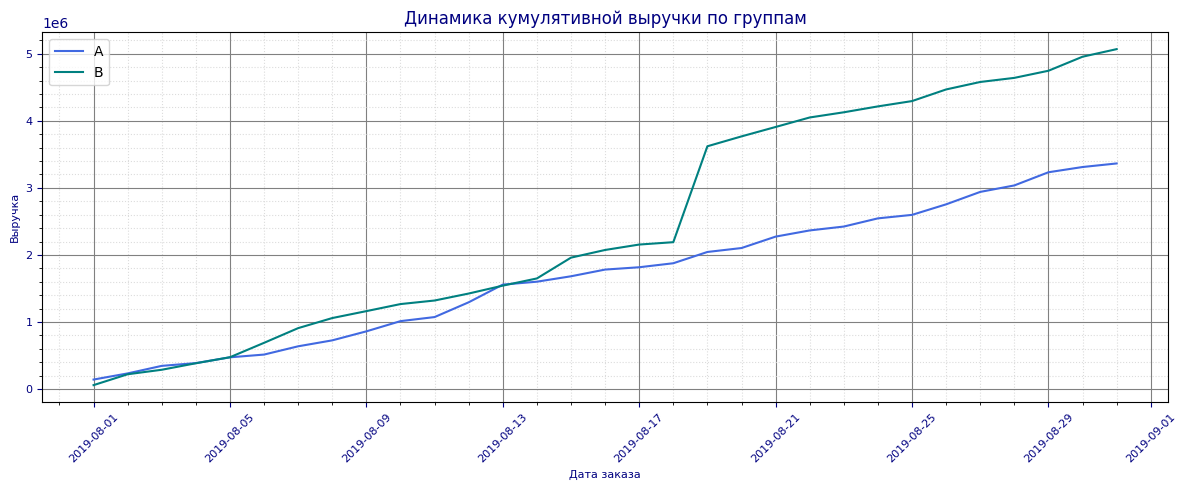

In [33]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cumulative_data_gr_a['date'], cumulative_data_gr_a['cumulative_group_revenue'], 
        color='royalblue', label='A')
ax.plot(cumulative_data_gr_b['date'], cumulative_data_gr_b['cumulative_group_revenue'], 
        color='teal', label='B')
ax.set_title('Динамика кумулятивной выручки по группам', color='navy')
ax.set_xlabel('Дата заказа', fontsize=8, color='navy')
ax.set_ylabel('Выручка', fontsize=8, color='navy')
ax.tick_params(colors='navy', labelsize=8)
ax.minorticks_on()
ax.grid(which='minor', color='gainsboro', linestyle=':')
ax.grid(which='major', color='grey', linestyle='-')  # основная сетка
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

<font color='Darkblue'>Из графика следует, что</font><br>
<font color='Darkblue'>- на протяжении почти всего периода наблюдения выручка по группе В превышает выручку по группе А</font><br>
<font color='Darkblue'><b>- 19 августа произошел существенный скачек выручки по группе В, что может быть связано либо с дорогостоящим заказом, либо с большим количеством заказов в этот день</font><br>

### Динамика кумулятивного среднего чека

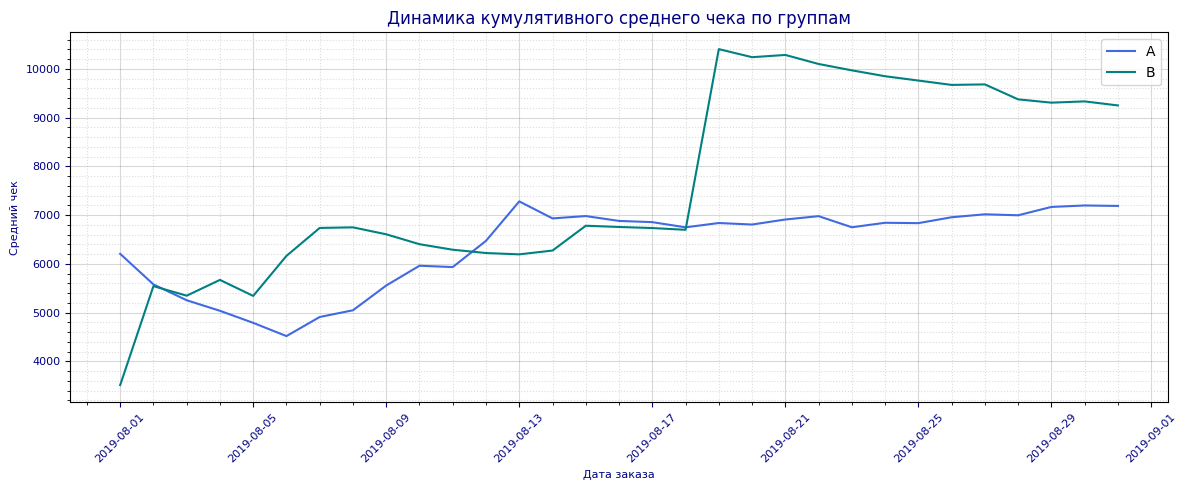

In [34]:
fig, ax = plt.subplots(figsize=(12, 5))

# Добавляем проверку на деление на ноль
avg_bill_a = cumulative_data_gr_a['cumulative_group_revenue'] / cumulative_data_gr_a['orders'].replace(0, np.nan)
avg_bill_b = cumulative_data_gr_b['cumulative_group_revenue'] / cumulative_data_gr_b['orders'].replace(0, np.nan)

ax.plot(cumulative_data_gr_a['date'], avg_bill_a, color='royalblue', label='A')
ax.plot(cumulative_data_gr_b['date'], avg_bill_b, color='teal', label='B')
ax.set_title('Динамика кумулятивного среднего чека по группам', color='navy')
ax.set_xlabel('Дата заказа', fontsize=8, color='navy')
ax.set_ylabel('Средний чек', fontsize=8, color='navy')
ax.tick_params(colors='navy', labelsize=8)
ax.minorticks_on()
ax.grid(which='major', color='grey', linestyle='-', alpha=0.3)
ax.grid(which='minor', color='gainsboro', linestyle=':')
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

<font color='Darkblue'>Из графика кумулятивного среднего чека видно, что</font><br>
<font color='Darkblue'>- за исключением 1 августа и периода с 12 по 18 августа средний чек по группе В превышает средний чек по группе А</font><br>
<font color='Darkblue'><b>- также 19 августа виден существенный скачек среднего чека группы В, что говорит в пользу одного дорогостоящего заказа, сделанного в этот день</font><br>

### Относительное изменение кумулятивного среднего чека группы B к группе A

In [35]:
# построим таблицу, объединяющую данные по группе А и группе В
merge_cumulative_data = cumulative_data_gr_a.merge(cumulative_data_gr_b, left_on = 'date', right_on = 'date', how = 'left', suffixes = ['_a', '_b'])
merge_cumulative_data.head()

,date,group_a,orders_a,buyers_a,cumulative_group_revenue_a,visitors_a,conversion_a,group_b,orders_b,buyers_b,cumulative_group_revenue_b,visitors_b,conversion_b
0,2019-08-01,A,23,19,142779,719,0.032,B,17,17,59758,713,0.024
1,2019-08-02,A,42,36,234381,1338,0.031,B,40,39,221801,1294,0.031
2,2019-08-03,A,66,60,346854,1845,0.036,B,54,53,288850,1803,0.030
3,2019-08-04,A,77,71,388030,2562,0.030,B,68,66,385740,2573,0.026
4,2019-08-05,A,99,92,474413,3318,0.030,B,89,87,475648,3280,0.027


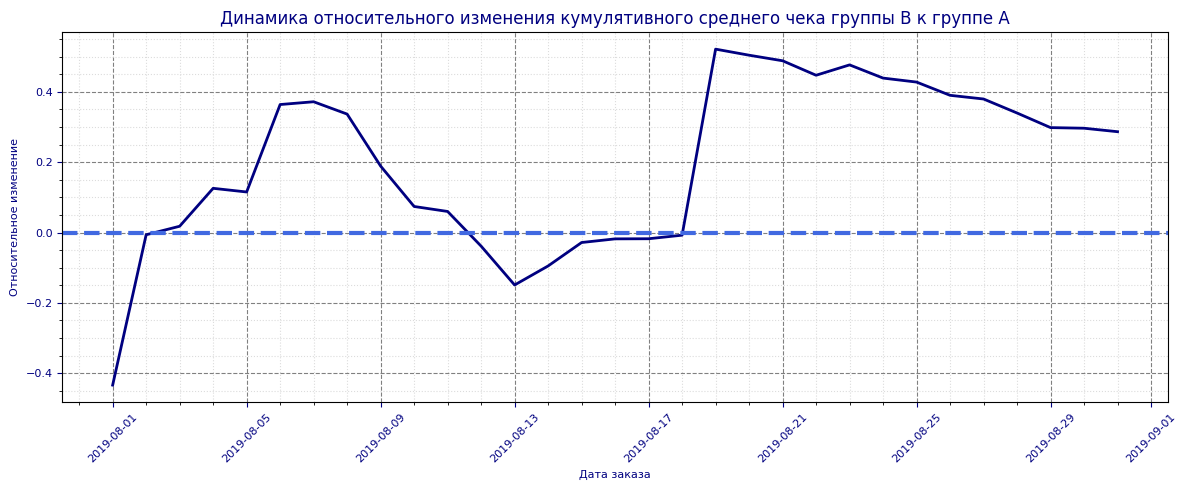

In [36]:
fig, ax = plt.subplots(figsize=(12, 5))

# Выносим расчет в отдельную переменную для читаемости
avg_bill_a = merge_cumulative_data['cumulative_group_revenue_a'] / merge_cumulative_data['orders_a'].replace(0, np.nan)
avg_bill_b = merge_cumulative_data['cumulative_group_revenue_b'] / merge_cumulative_data['orders_b'].replace(0, np.nan)
rel_change = (avg_bill_b / avg_bill_a) - 1

# Убираем inf и nan
rel_change = rel_change.replace([np.inf, -np.inf], np.nan)

ax.plot(merge_cumulative_data['date'], rel_change, color='navy', linewidth=2)
ax.set_title('Динамика относительного изменения кумулятивного среднего чека группы В к группе А', color='navy')
ax.set_xlabel('Дата заказа', fontsize=8, color='navy')
ax.set_ylabel('Относительное изменение', fontsize=8, color='navy')
ax.tick_params(colors='navy', labelsize=8)
ax.minorticks_on()
ax.grid(which='minor', color='gainsboro', linestyle=':')
ax.grid(which='major', color='grey', linestyle='--')
ax.axhline(y=0, color='royalblue', linestyle='--', linewidth=3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show() 

<font color='Darkblue'>Из графика относительного изменения кумулятивного среднего чека видно</font><br>
<font color='Darkblue'> - несколько резких скачков уровня среднего  чека - 2, 6 и 19 августа, что может свидетельствовать о дорогостоящих заказах посетителй группы В в эти дни</font><br>
<font color='Darkblue'><b> - начиная с 19 августа, устойчивое превышение кумулятивного среднего чека группы В относительно кумулятивного среднего чека группы А на ~40% , что, как уже выше было видно, стало следствием дорогостоящего заказа, сделанного 19 августа пользователем группы В</font><br>

### Кумулятивное среднее количество заказов на посетителя по группам

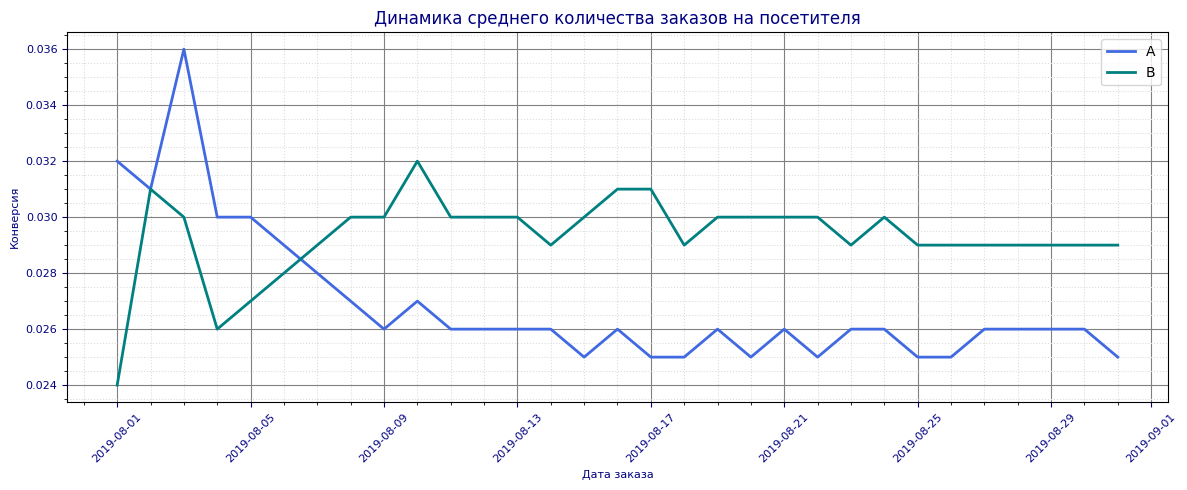

In [37]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(merge_cumulative_data['date'], merge_cumulative_data['conversion_a'], 
        color='royalblue', label='A', linewidth=2)
ax.plot(merge_cumulative_data['date'], merge_cumulative_data['conversion_b'], 
        color='teal', label='B', linewidth=2)
ax.set_title('Динамика среднего количества заказов на посетителя', color='navy', fontsize=12)
ax.set_xlabel('Дата заказа', fontsize=8, color='navy')
ax.set_ylabel('Конверсия', fontsize=8, color='navy')
ax.tick_params(colors='navy', labelsize=8)
ax.minorticks_on()
ax.grid(which='major', color='grey', linestyle='-')
ax.grid(which='minor', color='gainsboro', linestyle=':')
ax.legend()
plt.xticks(rotation=45)  # rotation все еще можно через plt
plt.tight_layout()
plt.show()

<font color='Darkblue'>График динамики среднего количества заказов на посетителя  отражает, что</font><br>
<font color='Darkblue'>- в течение первой недели августа конверсия по группе А была выше, чем по группе В</font><br>
<font color='Darkblue'><b>- начиная 7 августа конверсия группы В стабильно выше конверсии группы А, что в целом может подтверждать предположение об эффективности нововведений магазина</font><br>

### Относительное изменение кумулятивного среднего количества заказов на посетителя группы B к группе А

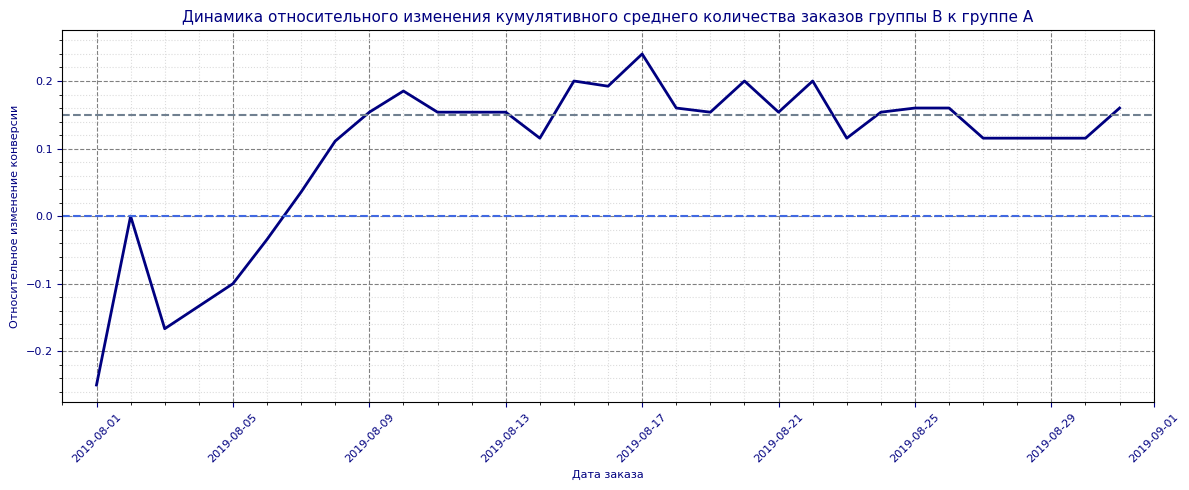

In [38]:
fig, ax = plt.subplots(figsize=(12, 5))

# Выносим расчет в отдельную переменную
rel_change = (merge_cumulative_data['conversion_b'] / merge_cumulative_data['conversion_a'].replace(0, np.nan)) - 1
rel_change = rel_change.replace([np.inf, -np.inf], np.nan)

ax.plot(merge_cumulative_data['date'], rel_change, color='navy', linewidth=2)
ax.set_title('Динамика относительного изменения кумулятивного среднего количества заказов группы В к группе А', 
             color='navy', fontsize=11)
ax.set_xlabel('Дата заказа', fontsize=8, color='navy')
ax.set_ylabel('Относительное изменение конверсии', fontsize=8, color='navy')  # Исправлено!
ax.tick_params(colors='navy', labelsize=8)
ax.minorticks_on()
ax.grid(which='major', color='grey', linestyle='--')
ax.grid(which='minor', color='gainsboro', linestyle=':')
ax.axhline(y=0, color='royalblue', linestyle='--', linewidth=1.5)
ax.axhline(y=0.15, color='slategrey', linestyle='--', linewidth=1.5)
ax.set_xlim(pd.Timestamp('2019-07-31'), pd.Timestamp('2019-09-01'))
ax.set_ylim(-0.275, 0.275)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()        

<font color='Darkblue'>График динамики относительного изменения кумулятивного количества заказов группы В к группе А отражает</font><br>
<font color='Darkblue'>- с 3 августа устойчивый рост конверсии группы В относительно уровня конверсии группы А</font><br>
<font color='Darkblue'><b>- начиная с 9 августа стабилизации превышения конверсии группы В над конверсией группы А на 15%</font><br>

### Резюме

<font color='Darkblue'> Анализ кумулятивных метрик показал, что</font><br>
<font color='Darkblue'>- на протяжении почти всего периода наблюдения выручка по группе В превышает выручку по группе А
<font color='Darkblue'>- 19 августа посетитель из группы В осуществил дорогостоящую покупку, которая существенно отразилась на показателях выручки и среднего чека по группе В
<font color='Darkblue'>- за исключением 1 августа и периода с 12 по 18 августа <font color='Darkblue'><b>средний чек по группе В превышает средний чек по группе А</font><br>
<font color='Darkblue'><b> - начиная с 19 августа, устойчивое превышение кумулятивного среднего чека группы В относительно кумулятивного среднего чека группы А на ~40% </font><br>
<font color='Darkblue'><b>- за исключением 1й недели августа конверсия группы В стабильно выше конверсии группы А, что в целом может подтверждать предположение об эффективности нововведений магазина</font><br>
<font color='Darkblue'>- с 3 августа устойчивый рост конверсии группы В относительно уровня конверсии группы и, начиная <font color='Darkblue'><b>с 9 августа, стабильное превышение конверсии группы В над конверсией группы А на 15%</font><br>

## Анализ выбросов

### Определение аномальных пользователей по количеству заказов

#### Распределение количества заказов по пользователям

In [39]:
# Рассчитаем число заказов по пользователям
orders_by_user = orders.groupby(orders['visitor_id'], as_index=False) \
                        .agg({'order_id' : 'nunique'})
orders_by_user.columns = ['visitor_id', 'orders_amnt']
order_counts = orders_by_user.orders_amnt.value_counts()

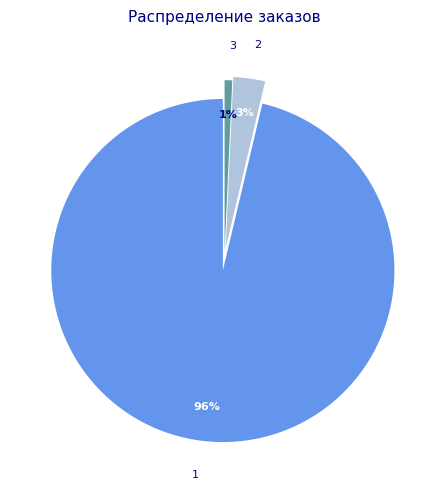

In [40]:
# построим график распределения количества заказов по пользователям
fig, ax = plt.subplots(figsize=(6, 5))

# Увеличиваем gap между сегментами для читаемости
wedges, texts, autotexts = ax.pie(
    order_counts.values, 
    labels=order_counts.index,
    autopct='%1.0f%%',
    colors=['cornflowerblue', 'lightsteelblue', 'cadetblue'],
    startangle=90,
    explode=(0.08, 0.05, 0.03),
    textprops={'fontsize': 8, 'color': 'navy'},
    pctdistance=0.8,
    labeldistance=1.2
)

# Проценты белым на темных сегментах
for i, autotext in enumerate(autotexts):
    if i < 2:  # для первых двух сегментов (темных)
        autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(8)

ax.set_title('Распределение заказов', color='navy', fontsize=11, pad=15)

plt.tight_layout()
plt.show()

<font color='DarkBlue'>Из представленного графика видно, что</font><br>
<font color='DarkBlue'><b>- основное количество пользователей (96%) осуществляет 1 заказ</font><br>
<font color='DarkBlue'>- по 2 заказа и 3 заказа осуществляет совсем незначительное количество пользователей</font><br>

In [41]:
print(np.percentile(orders_by_user['orders_amnt'], [95, 99]))

[1. 2.]


<font color='DarkBlue'>Из расчетов видно, что </font><br>
<font color='DarkBlue'>- больше 2х заказов осуществило не более 5 %</font><br>
<font color='DarkBlue'>- больше 3х заказов осуществило не более 1 %</font><br>
<font color='DarkBlue'><b>Установим предельное количество заказов равным 2, приниамя, что 3 заказа является аномальным для пользователей магазина</font><br>

### Определение аномальных пользователей по стоимости заказов

#### Распределение стоимости заказов по пользователям

95% заказов до: 26785.00
99% заказов до: 53904.00
Макс заказ: 1294500.00


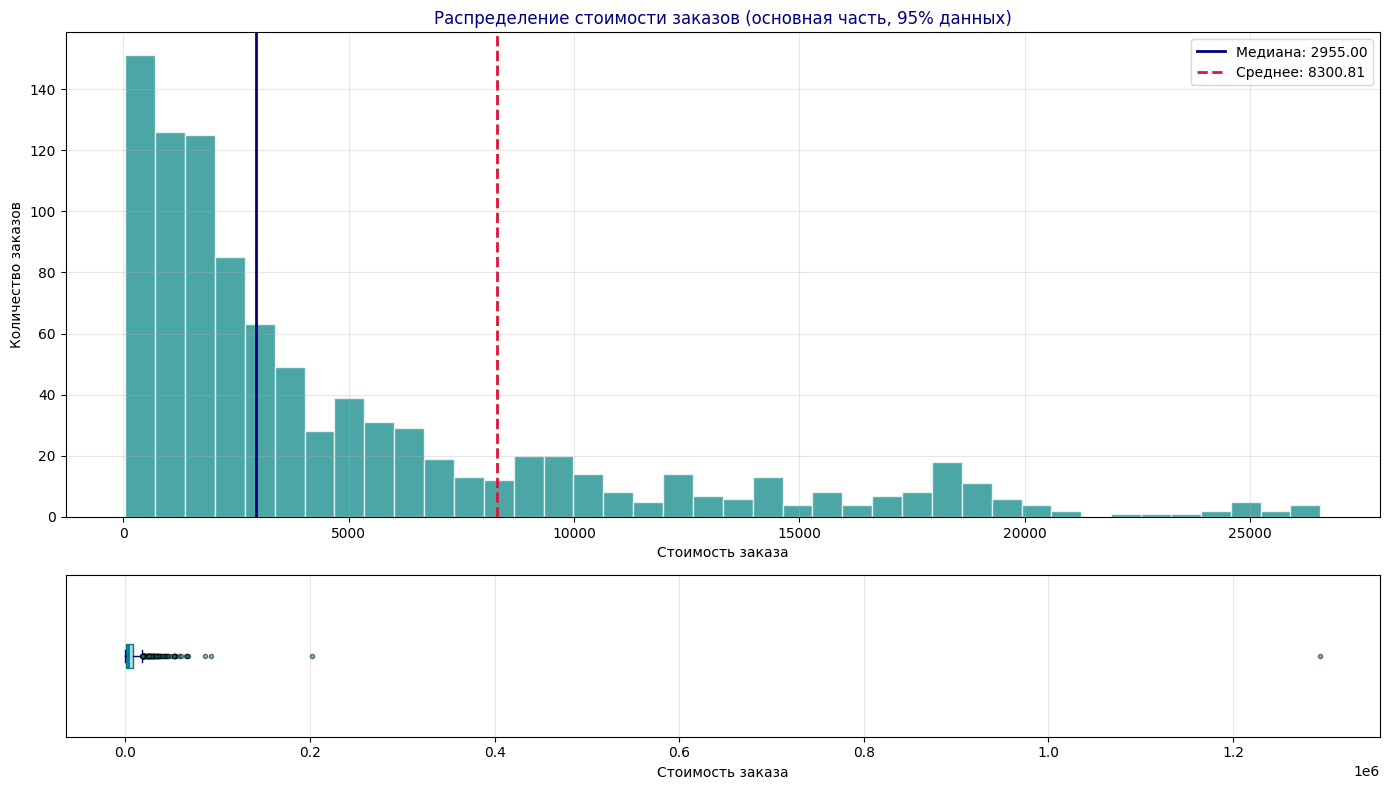

In [42]:
# построим график распределения количества заказов по пользователям
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), 
                                gridspec_kw={'height_ratios': [3, 1]})

# Статистика для определения границ
q95 = orders['revenue'].quantile(0.95)
q99 = orders['revenue'].quantile(0.99)
print(f"95% заказов до: {q95:.2f}")
print(f"99% заказов до: {q99:.2f}")
print(f"Макс заказ: {orders['revenue'].max():.2f}")

# Гистограмма (основная часть)
ax1.hist(orders['revenue'][orders['revenue'] <= q95], bins=40, 
         color='teal', edgecolor='white', alpha=0.7)
ax1.axvline(orders['revenue'].median(), color='navy', linestyle='-', 
            linewidth=2, label=f'Медиана: {orders["revenue"].median():.2f}')
ax1.axvline(orders['revenue'].mean(), color='crimson', linestyle='--', 
            linewidth=2, label=f'Среднее: {orders["revenue"].mean():.2f}')
ax1.set_title('Распределение стоимости заказов (основная часть, 95% данных)', 
              color='navy', fontsize=12)
ax1.set_xlabel('Стоимость заказа', fontsize=10)
ax1.set_ylabel('Количество заказов', fontsize=10)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box plot (полное распределение с выбросами)
ax2.boxplot(orders['revenue'], vert=False, patch_artist=True,
            boxprops=dict(color='teal', facecolor='lightblue'),
            whiskerprops=dict(color='navy'),
            capprops=dict(color='navy'),
            medianprops=dict(color='teal', linewidth=2),
            flierprops=dict(marker='o', markerfacecolor='teal', 
                           markersize=3, alpha=0.5))
ax2.set_xlabel('Стоимость заказа', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_yticks([])

plt.tight_layout()
plt.show()

<font color='DarkBlue'>Из представленного графика видно, что</font><br>
<font color='DarkBlue'><b>- основное количество пользователей осуществляет заказ в пределах 100 тысяч</font><br>
<font color='DarkBlue'>- есть заметная аномалия - заказы на сумму более 200 тыс </font><br>

Статистика распределения стоимости заказов:
Нижняя граница (5%): 300.00
Медиана (50%): 2955.00
Верхняя граница (95%): 26785.00
Среднее: 8300.81
Всего заказов: 1016
Заказов в диапазоне 300.00 - 26785.00: 921 (90.6%)


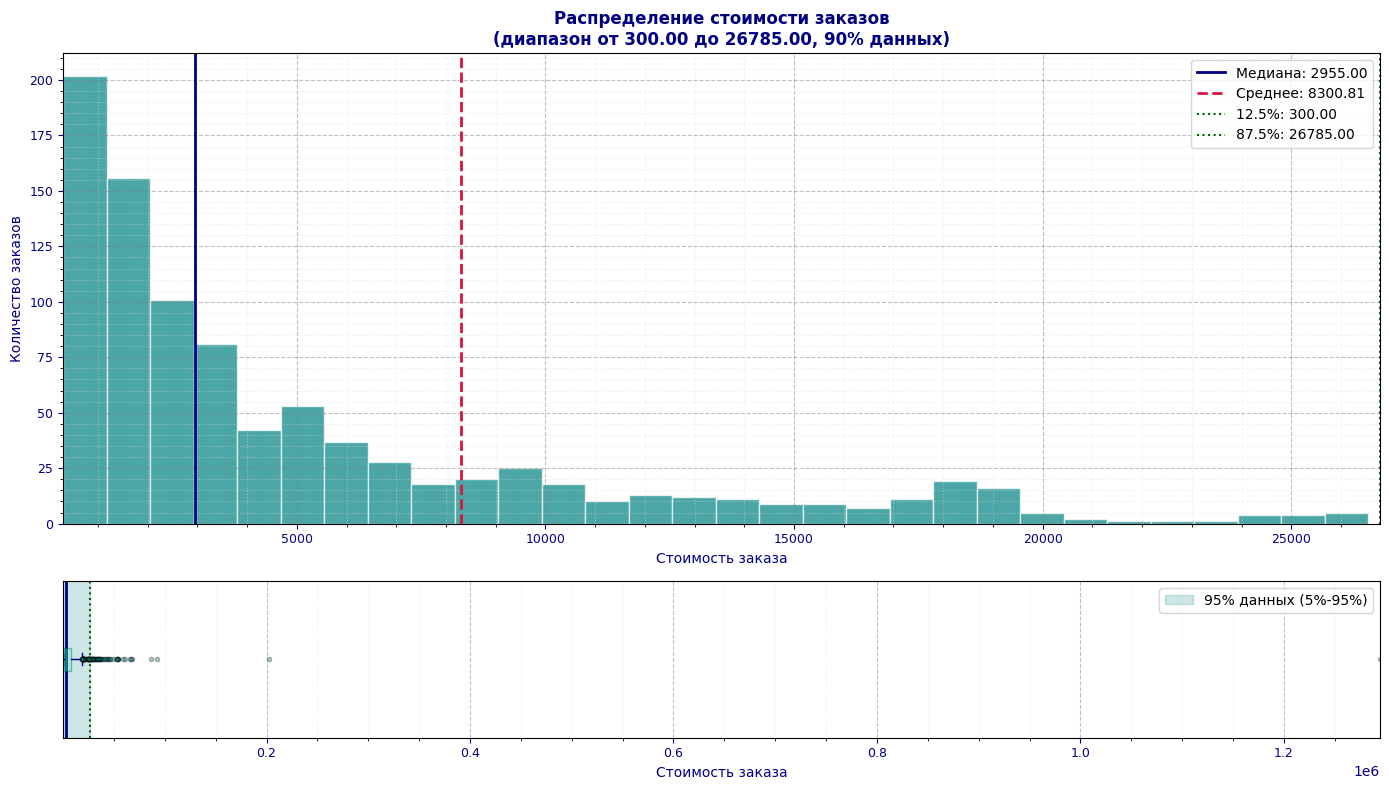

In [43]:
# Посмотрим более подробно распределение стоимости заказов в пределах межквартильного размаха
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), 
                                gridspec_kw={'height_ratios': [3, 1]})

# Рассчитываем статистику
q1 = orders['revenue'].quantile(0.05)  # нижняя граница
q3 = orders['revenue'].quantile(0.95)  # верхняя граница
median = orders['revenue'].median()
mean = orders['revenue'].mean()

print(f"Статистика распределения стоимости заказов:")
print(f"Нижняя граница (5%): {q1:.2f}")
print(f"Медиана (50%): {median:.2f}")
print(f"Верхняя граница (95%): {q3:.2f}")
print(f"Среднее: {mean:.2f}")
print(f"Всего заказов: {len(orders['revenue'])}")
print(f"Заказов в диапазоне {q1:.2f} - {q3:.2f}: {(orders['revenue'].between(q1, q3)).sum()} ({(orders['revenue'].between(q1, q3).sum()/len(orders)*100):.1f}%)")

# Ограничиваем данные для гистограммы
revenue_limited = orders['revenue'][orders['revenue'].between(q1, q3)]

# Гистограмма
ax1.hist(revenue_limited, bins=30, color='teal', edgecolor='white', alpha=0.7)
ax1.axvline(median, color='navy', linestyle='-', 
            linewidth=2, label=f'Медиана: {median:.2f}')
ax1.axvline(mean, color='crimson', linestyle='--', 
            linewidth=2, label=f'Среднее: {mean:.2f}')
ax1.axvline(q1, color='darkgreen', linestyle=':', 
            linewidth=1.5, label=f'12.5%: {q1:.2f}')
ax1.axvline(q3, color='darkgreen', linestyle=':', 
            linewidth=1.5, label=f'87.5%: {q3:.2f}')
ax1.set_title(f'Распределение стоимости заказов\n(диапазон от {q1:.2f} до {q3:.2f}, 90% данных)', 
              color='navy', fontsize=12, fontweight='bold')
ax1.set_xlabel('Стоимость заказа', fontsize=10, color='navy')
ax1.set_ylabel('Количество заказов', fontsize=10, color='navy')
ax1.set_xlim(q1, q3)
ax1.legend(loc='upper right')
ax1.minorticks_on()
ax1.grid(which='major', color='grey', linestyle='--', alpha=0.5)
ax1.grid(which='minor', color='gainsboro', linestyle=':', alpha=0.5)
ax1.tick_params(colors='navy', labelsize=9)

# Box plot с подсветкой нужного диапазона
box_data = [orders['revenue']]
bp = ax2.boxplot(box_data, vert=False, patch_artist=True,
                 boxprops=dict(color='teal', facecolor='lightblue', alpha=0.5),
                 whiskerprops=dict(color='navy'),
                 capprops=dict(color='navy'),
                 medianprops=dict(color='teal', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor='teal', 
                                markersize=3, alpha=0.3))

# Подсвечиваем нужный диапазон на box plot
ax2.axvspan(q1, q3, alpha=0.2, color='teal', label='95% данных (5%-95%)')
ax2.axvline(median, color='navy', linestyle='-', linewidth=2)
ax2.axvline(q1, color='darkgreen', linestyle=':', linewidth=1.5)
ax2.axvline(q3, color='darkgreen', linestyle=':', linewidth=1.5)

ax2.set_xlabel('Стоимость заказа', fontsize=10, color='navy')
ax2.set_xlim(orders['revenue'].min(), orders['revenue'].max())
ax2.minorticks_on()
ax2.grid(which='major', color='grey', linestyle='--', alpha=0.5)
ax2.grid(which='minor', color='gainsboro', linestyle=':', alpha=0.5)
ax2.tick_params(colors='navy', labelsize=9)
ax2.set_yticks([])
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [44]:
print(np.percentile(orders['revenue'], [95, 99]))

[26785. 53904.]


<font color='DarkBlue'>Расчет показывает, что</font><br>
<font color='DarkBlue'>- 95% пользователей магазина осуществили заказ на 26,785</font><br>
<font color='DarkBlue'>- у 99% пользователй заказ не превысил стоимости 53,904</font><br>
<font color='DarkBlue'><b>Установим предельную стоимость заказа равной 54 тыс.</font><font color='DarkBlue'>, приниамя, что заказ свыше 54 тыс. является аномальным для пользователей магазина</font>

### Аномальные пользователи

Исходя из результатов вышепроведенного анализа аномальными пользователями принимаем тех, кто сделал более 2х заказов и или сделал заказы на сумму больше 54 тыс. 

In [45]:
# Сформируем датасет с пользователи с количеством заказов - более 2
orders_by_user_a = orders[orders['group'] == 'A'] \
                    .groupby('visitor_id', as_index=False) \
                    .agg({'order_id' : pd.Series.nunique})
orders_by_user_a.columns = ['visitor_id', 'orders_amnt']
orders_by_user_b = orders[orders['group'] == 'B'] \
                    .groupby('visitor_id', as_index=False) \
                    .agg({'order_id' : pd.Series.nunique})
orders_by_user_b.columns = ['visitor_id', 'orders_amnt']
visitors_many_orders = pd.concat([
        orders_by_user_a[orders_by_user_a['orders_amnt'] > 2]['visitor_id'],
        orders_by_user_b[orders_by_user_b['orders_amnt'] > 2]['visitor_id']], axis=0,)
print(f'Пользователей, осуществивших более 2х заказов - {visitors_many_orders.count()} пользователей')

Пользователей, осуществивших более 2х заказов - 7 пользователей


In [46]:
# пользватели с заказами более 60 тыс.
visiors_exsp_orders = orders[orders['revenue'] >= 54000]['visitor_id']
print(f'Пользователей с аномальными размерами заказа - {visiors_exsp_orders.count()} пользователей')

Пользователей с аномальными размерами заказа - 9 пользователей


In [47]:
# объединим пользователей и получим искомый датасет с аномальными пользователями
abnormal_users = pd.concat([visitors_many_orders, visiors_exsp_orders], axis = 0) \
                    .drop_duplicates() \
                    .sort_values()
print(f'Общее количество "аномальных пользователей" - {abnormal_users.count()} пользователей')

Общее количество "аномальных пользователей" - 16 пользователей


### Резюме

<font color='DarkBlue'>В результате анализа данных были определены</font><font color='DarkBlue'><b>16 аномальных пользователей</font> - это пользователи, которые совершили</font><font color='DarkBlue'><b> более двух заказов</font><font color='DarkBlue'> или пользователи, которые совершили</font><font color='DarkBlue'><b> заказ на сумму, первышающую 54 тыс.</font>

## Статистическая значимость различий метрик по группам А/В теста

### Подготовка данных

In [48]:
# сфщормируем два датасета о ежедневном накопленном количестве посетителей по группам
# для группы А
visitors_daily_a = visitors[visitors['group'] == 'A'][['date', 'visitors']]
visitors_daily_a.columns = ['date','visitors_per_date_a']
visitors_cumulative_a = visitors_daily_a.apply(
                            lambda x: visitors_daily_a[visitors_daily_a['date'] <= x['date']] \
                                .agg({'date' : 'max', 'visitors_per_date_a' : 'sum'}), axis = 1,)
visitors_cumulative_a.columns = ['date', 'cumulative_visitors_a']

# для группы В
visitors_daily_b = visitors[visitors['group'] == 'B'][['date', 'visitors']]
visitors_daily_b.columns = ['date','visitors_per_date_b']
visitors_cumulative_b = visitors_daily_b.apply(
                            lambda x: visitors_daily_b[visitors_daily_b['date'] <= x['date']] \
                                .agg({'date' : 'max', 'visitors_per_date_b' : 'sum'}), axis = 1,)
visitors_cumulative_b.columns = ['date', 'cumulative_visitors_b']

In [49]:
# сфщормируем два датасета о ежедневной накопленной выручке по группам
# для группы А
orders_daily_a = orders[orders['group'] == 'A'][['date', 'order_id', 'visitor_id', 'revenue']] \
                    .groupby('date', as_index=False) \
                    .agg({'order_id' : pd.Series.nunique, 'revenue' : 'sum'}) 
orders_daily_a.columns = ['date','orders_per_date_a', 'revenue_per_date_a']
orders_cumulative_a = orders_daily_a.apply(
                            lambda x: orders_daily_a[orders_daily_a['date'] <= x['date']] \
                                .agg({'date' : 'max', 'orders_per_date_a' : 'sum', 'revenue_per_date_a' : 'sum'}), axis = 1,) \
                                .sort_values(by=['date'])
orders_cumulative_a.columns = ['date', 'cumulative_orders_a', 'cumulative_revenue_a']

# для группы В
orders_daily_b = orders[orders['group'] == 'B'][['date', 'order_id', 'visitor_id', 'revenue']] \
                    .groupby('date', as_index=False) \
                    .agg({'order_id' : pd.Series.nunique, 'revenue' : 'sum'}) 
orders_daily_b.columns = ['date','orders_per_date_b', 'revenue_per_date_b']
orders_cumulative_b = orders_daily_b.apply(
                            lambda x: orders_daily_b[orders_daily_a['date'] <= x['date']] \
                                .agg({'date' : 'max', 'orders_per_date_b' : 'sum', 'revenue_per_date_b' : 'sum'}), axis = 1,) \
                                .sort_values(by=['date'])
orders_cumulative_b.columns = ['date', 'cumulative_orders_b', 'cumulative_revenue_b']

In [50]:
# объединим данные Групп по посетителям и выручке
data = orders_daily_a.merge \
            (orders_daily_b, left_on = 'date', right_on = 'date', how = 'left') \
        .merge(orders_cumulative_a, left_on = 'date', right_on = 'date', how = 'left') \
        .merge(orders_cumulative_b, left_on = 'date', right_on = 'date', how = 'left') \
        .merge(visitors_daily_a, left_on = 'date', right_on = 'date', how = 'left') \
        .merge(visitors_daily_b, left_on = 'date', right_on = 'date', how = 'left') \
        .merge(visitors_cumulative_a, left_on = 'date', right_on = 'date', how = 'left') \
        .merge(visitors_cumulative_b, left_on = 'date', right_on = 'date', how = 'left')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   date                   31 non-null     object
 1   orders_per_date_a      31 non-null     int64 
 2   revenue_per_date_a     31 non-null     int64 
 3   orders_per_date_b      31 non-null     int64 
 4   revenue_per_date_b     31 non-null     int64 
 5   cumulative_orders_a    31 non-null     int64 
 6   cumulative_revenue_a   31 non-null     int64 
 7   cumulative_orders_b    31 non-null     int64 
 8   cumulative_revenue_b   31 non-null     int64 
 9   visitors_per_date_a    31 non-null     int64 
 10  visitors_per_date_b    31 non-null     int64 
 11  cumulative_visitors_a  31 non-null     int64 
 12  cumulative_visitors_b  31 non-null     int64 
dtypes: int64(12), object(1)
memory usage: 3.3+ KB


Таким образом, мы сформировали необходимый для дальнейшего анализа свод данных по датам, который выключает в себя ежедневные показатели 
- ежедневное и накопленное количество заказов по группам
- ежедневное и накопленное количество посетителей по группам
- ежедневная и накопленная выручка по группам

Зададим функцию для расчета статистической значимости различий

In [51]:
def significant_difference(data_a, data_b):
    alpha = 0.05
    p_value = st.mannwhitneyu(data_a, data_b)[1]
    
    if p_value < alpha:
        print('Разница метрик между группами A и B статистически значима: p-value - {0:.3f}. Нулевая гипотеза о равенстве метрик отвергнута'.format(p_value))
    else:
        print('Разница метрик между группами A и B статистически НЕ значима: p-value - {0:.3f}. Нулевая гипотеза о равенстве метрик не может быть отвергнута'.format(p_value))

    print('Относительный прирост В к А составляет {0:.1%}'.format((data_b.mean() / data_a.mean()) - 1))
    

### Статистическая значимость различий в среднем количестве заказов на посетителя между группами

In [52]:
# создадим две переменные (по каждой группе), в которых каждому пользовталею будет соответсвовать число заказов, которые он сделал,
# либо 0, если он не делал ни одного заказа
sample_a = pd.concat([orders_by_user_a['orders_amnt'], \
                      pd.Series(0, index = np.arange(data['visitors_per_date_a'].sum() - len(orders_by_user_a['orders_amnt'])), name = 'orders_amnt'),], \
                      axis = 0)

sample_b = pd.concat([orders_by_user_b['orders_amnt'], \
                      pd.Series(0, index = np.arange(data['visitors_per_date_b'].sum() - len(orders_by_user_a['orders_amnt'])), name = 'orders_amnt'),], \
                      axis = 0)

In [53]:
# посчитаем статистическую разницу по "сырым" данным
significant_difference(sample_a, sample_b)

Разница метрик между группами A и B статистически значима: p-value - 0.013. Нулевая гипотеза о равенстве метрик отвергнута
Относительный прирост В к А составляет 15.5%


2. статистическая значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным

In [54]:
# создадим две переменные заказов (по каждой группе) по очищенным данным - пользователи, определенные в abnormal_users
sample_a_filtred = pd.concat([orders_by_user_a[np.logical_not(orders_by_user_a['visitor_id'].isin(abnormal_users))] \
                              ['orders_amnt'], \
                      pd.Series(0, index = np.arange(data['visitors_per_date_a'].sum() - len(orders_by_user_a['orders_amnt'])), name = 'orders_amnt'),], \
                      axis = 0)

sample_b_filtred = pd.concat([orders_by_user_b[np.logical_not(orders_by_user_b['visitor_id'].isin(abnormal_users))] \
                              ['orders_amnt'], \
                      pd.Series(0, index = np.arange(data['visitors_per_date_b'].sum() - len(orders_by_user_a['orders_amnt'])), name = 'orders_amnt'),], \
                      axis = 0)

In [55]:
# посчитаем статистическую разницу по "сырым" данным
significant_difference(sample_a_filtred, sample_b_filtred)

Разница метрик между группами A и B статистически значима: p-value - 0.009. Нулевая гипотеза о равенстве метрик отвергнута
Относительный прирост В к А составляет 18.4%


<font color='DarkBlue'><b><i>Комментарий</font>

<font color='DarkBlue'>Таким образом из представленных выше расчетов следует:</font><br>
<font color='DarkBlue'><b>- как по "сырым", так и по "очищенным" данным разница в конверсии между группами статистически значима</font><font color='DarkBlue'> - p-value составляет 0,13 и 0,009 соответственно, нулевая гипотеза о равенстве конверсий отвергнута</font><br>
<font color='DarkBlue'><b>- как по "сырым", так и по "очищенным" относительный прирост конверсии группы В к группе А составляет 15,5% и 18,4% соответственно</font>

### Статистическая значимость различий в среднем чеке заказа между группами

In [56]:
significant_difference(orders[orders['group'] == 'A']['revenue'], \
                       orders[orders['group'] == 'B']['revenue'])

Разница метрик между группами A и B статистически НЕ значима: p-value - 0.829. Нулевая гипотеза о равенстве метрик не может быть отвергнута
Относительный прирост В к А составляет 28.7%


In [57]:
significant_difference(orders[np.logical_and(orders['group'] == 'A', \
                       np.logical_not(orders['visitor_id'].isin(abnormal_users)),)]['revenue'], \
                       orders[np.logical_and(orders['group'] == 'B', \
                       np.logical_not(orders['visitor_id'].isin(abnormal_users)),)]['revenue'])

Разница метрик между группами A и B статистически НЕ значима: p-value - 0.788. Нулевая гипотеза о равенстве метрик не может быть отвергнута
Относительный прирост В к А составляет -3.2%


<font color='DarkBlue'><b><i>Комментарий</font>

<font color='DarkBlue'>Таким образом из представленных выше расчетов следует:</font><br>
<font color='DarkBlue'><b>- как по "сырым", так и по "очищенным" данным разница в среднем чеке между группами статистически НЕ значима</b> - p-value составляет 0,829 и 0,788 соответсвенно, нулевая гипотеза о равенстве среднего чека по группам НЕ может быть отвергнута</font><br>
<font color='DarkBlue'><b>- по "сырым" данным относительный прирост среднего чека группы В к группе А составляет 28,7%, тогда как по "очищенным" данным этот прирост отрицательный - 3,2%</font>

### Резюме

<font color='DarkBlue'><b>Как по "сырым", так и по "очищенным" данным разница в конверсии между группами статистически значима</b> - p-гипотеза о равенстве конверсий отвергнута, прирост конверсии группы В к группе А составляет 15,5% и 18,4% соответственно</font><br>
<font color='DarkBlue'><b>Как по "сырым", так и по "очищенным" данным разница в среднем чеке между группами статистически НЕ значима</b> гипотеза о равенстве среднего чека по группам НЕ может быть отвергнута.<b> Относительный прирост среднего чека группы В к группе А по "сырым" данным составляет 28,7%, однако по "очищенным" данным этот прирост незначительно-отрицательный - 3,2%</font><br>
<font color='DarkBlue'>Исходя из вышеизложенного, можно констатировать, что <br> ✔ в результате реализованных мероприятий, увеличилась конверсия пользователей <br>✔  мероприятия привели к увеличению среднего чека, только если принимать во внимание аномальные заказы<br><b><i>✔  возможно оставновить тест, признав, что реализованные мероприятия эффективны</font><br>

## Заключение

<font color='Navy'><i>1. Для исследования предоставлены<br>- данные о 9 прорейтингованных гипотезах о возможных действиях, направленных на повышение выручки интернет-магазина<br>- 2 датасета о количестве и стоимости заказов и количестве посетителей интернет-магазина в период с 01 по 31 августа 2019 года с разбивкой по группам А/В-тестирования<br>

<font color='Navy'><i>2. Приоритезация гипотез методами ICЕ и RICE показала что <b>исходя из результатов ранжирования методом ICE</b> в дальнейшем в первую очередь целесообразно анализировать <b>гипотезу о запуске акции, дающей скидку на товар в день рождения</b>, тогда как <b>ранжирование методом RICE определило как более приоритетную гипотезу о целесообразности добавления формы подписки на все основные страницы</b><br>✔ С учетом того, что значимость фактора охвата достаточно высока для интернет-магазина, и при условии, что ранги, связанные с влиянием на достижение цели и уверенностью в том, что идея действительно окажет прогнозируемое воздействие, достаточно высоки, <b>для дальнейшего анализа рекомендуется в первую очередь рассматривать гипотезу о целесообразности добавления формы подписки на все основные страницы, которая позволит собрать базу клиентов для email-рассылок

<font color='Navy'><i>3. В рамках подготовки к А/В тестированию выявлено <b>58 посетителей, учтенных как в группе А, так и в группе В</b>, которые составили 5.6% от общего количества уникальных пользователей магазина и совершили 181 покупок (15.12% всех покупок в интернет- магазине). Общая выручка от этих посетителей, составилаа 1,558,935 (15.60% выручки от всех покупок).<br><b><i>✔ Данные об этих пользователях были исключены из дальнейшего исследования

<font color='Darkblue'>4. Анализ кумулятивных метрик показал, что<br>- на протяжении почти всего периода наблюдения выручка по группе В превышает выручку по группе А<br>- <b><i>19 августа посетитель из группы В осуществил дорогостоящую покупку, которая существенно отразилась на показателях выручки и среднего чека по группе В</b></i><br>- за исключением 1 августа и периода с 12 по 18 августа <b><i>средний чек по группе В превышает средний чек по группе А, и начиная с 19 августа кумулятивный средний чека группы В выше относительно кумулятивного среднего чека группы А на ~40%</b></i><br><i>- за исключением 1й недели августа <b>конверсия группы В стабильно выше конверсии группы А, что в целом может подтверждать предположение об эффективности нововведений магазина</b><br>- с 3 августа устойчивый рост конверсии группы В относительно уровня конверсии группы и, начиная <b>с 9 августа, стабильное превышение конверсии группы В над конверсией группы А на 15%<br>

<font color='DarkBlue'>5. В результате анализа данных были определены<b>16 аномальных пользователей - это пользователи, которые совершили более двух заказов или пользователи, которые совершили заказ на сумму, первышающую 54 тыс.

<font color='DarkBlue'>6. Анализ статистической значимости различий метрик показал, что<br>- как по "сырым", так и по "очищенным" данным <i>разница в конверсии между группами статистически значима</i><br>- как по "сырым", так и по "очищенным" данным <i>разница в среднем чеке между группами статистически НЕ значима</i><br><br>Таким образом <br> ✔ <b><i><u>в результате реализованных мероприятий, увеличилась конверсия пользователей <br>✔  мероприятия привели к увеличению среднего чека, при условии использования "сырых" данных (не исключения аномальных пользователей)<br><b><i><u>✔  возможно остановить тест, признав, что реализованные мероприятия эффективны</font><br>